In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats

In [3]:
housing = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/Ames_Housing_Data1.tsv", sep='\t')
housing.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2931 non-null   int64  
 1   PID              2931 non-null   int64  
 2   MS SubClass      2931 non-null   int64  
 3   MS Zoning        2931 non-null   object 
 4   Lot Frontage     2441 non-null   float64
 5   Lot Area         2931 non-null   int64  
 6   Street           2931 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2931 non-null   object 
 9   Land Contour     2931 non-null   object 
 10  Utilities        2931 non-null   object 
 11  Lot Config       2931 non-null   object 
 12  Land Slope       2931 non-null   object 
 13  Neighborhood     2931 non-null   object 
 14  Condition 1      2931 non-null   object 
 15  Condition 2      2931 non-null   object 
 16  Bldg Type        2931 non-null   object 
 17  House Style   

In [5]:
housing["SalePrice"].describe()

count      2931.000000
mean     180807.729785
std       79875.557267
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

# Cleaning Data

In [6]:
# missing values
missing_values = housing.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]
missing_values_percentage = (missing_values / len(housing)) * 100
missing_values_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_values_percentage
})
print(missing_values_df)

                Missing Values  Percentage
Pool QC                   2918   99.556465
Misc Feature              2825   96.383487
Alley                     2733   93.244626
Fence                     2359   80.484476
Mas Vnr Type              1775   60.559536
Fireplace Qu              1422   48.515865
Lot Frontage               490   16.717844
Garage Cond                159    5.424770
Garage Finish              159    5.424770
Garage Yr Blt              159    5.424770
Garage Qual                159    5.424770
Garage Type                157    5.356534
Bsmt Exposure               83    2.831798
BsmtFin Type 2              81    2.763562
Bsmt Qual                   80    2.729444
Bsmt Cond                   80    2.729444
BsmtFin Type 1              80    2.729444
Mas Vnr Area                23    0.784715
Bsmt Full Bath               2    0.068236
Bsmt Half Bath               2    0.068236
BsmtFin SF 1                 1    0.034118
Garage Cars                  1    0.034118
Electrical 

In [7]:
categorical_features = housing.select_dtypes(include=['object']).columns
print(categorical_features)

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')


In [8]:
# Categorical features with missing values are filled with 'None'
housing[categorical_features] = housing[categorical_features].fillna('None')

In [9]:
numerical_features = housing.select_dtypes(include=[np.number]).columns
print(numerical_features)

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='object')


In [10]:
# Fill numerical features with median values
housing[numerical_features] = housing[numerical_features].fillna(housing[numerical_features].median())

In [11]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2931 entries, 0 to 2930
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2931 non-null   int64  
 1   PID              2931 non-null   int64  
 2   MS SubClass      2931 non-null   int64  
 3   MS Zoning        2931 non-null   object 
 4   Lot Frontage     2931 non-null   float64
 5   Lot Area         2931 non-null   int64  
 6   Street           2931 non-null   object 
 7   Alley            2931 non-null   object 
 8   Lot Shape        2931 non-null   object 
 9   Land Contour     2931 non-null   object 
 10  Utilities        2931 non-null   object 
 11  Lot Config       2931 non-null   object 
 12  Land Slope       2931 non-null   object 
 13  Neighborhood     2931 non-null   object 
 14  Condition 1      2931 non-null   object 
 15  Condition 2      2931 non-null   object 
 16  Bldg Type        2931 non-null   object 
 17  House Style   

# Handling Duplicates

In [12]:
duplicated_rows = housing[housing.duplicated(['PID'])]
duplicated_rows

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000


In [13]:
duplicated_rows_remove = housing.drop_duplicates()
duplicated_rows_remove

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000
2,2,526350040,20,RH,80.0,11622,Pave,None,Reg,Lvl,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
3,3,526351010,20,RL,81.0,14267,Pave,None,IR1,Lvl,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
4,4,526353030,20,RL,93.0,11160,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2010,WD,Normal,244000
5,5,527105010,60,RL,74.0,13830,Pave,None,IR1,Lvl,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,2926,923275080,80,RL,37.0,7937,Pave,None,IR1,Lvl,...,0,None,GdPrv,None,0,3,2006,WD,Normal,142500
2927,2927,923276100,20,RL,68.0,8885,Pave,None,IR1,Low,...,0,None,MnPrv,None,0,6,2006,WD,Normal,131000
2928,2928,923400125,85,RL,62.0,10441,Pave,None,Reg,Lvl,...,0,None,MnPrv,Shed,700,7,2006,WD,Normal,132000
2929,2929,924100070,20,RL,77.0,10010,Pave,None,Reg,Lvl,...,0,None,None,None,0,4,2006,WD,Normal,170000


In [14]:
housing.index.is_unique

True

# Exploratory Analysis

In [15]:
# Correlations with SalePrice
correlations = housing.corr(numeric_only=True)['SalePrice']

# Remove SalePrice from the list so you don't correlate it with itself
correlations = correlations.drop('SalePrice')

# Filter for strong features
top_features = correlations[abs(correlations) > 0.5].sort_values(ascending=False)

print("There are {} strongly correlated features with SalePrice:\n{}".format(len(top_features), top_features))

There are 11 strongly correlated features with SalePrice:
Overall Qual      0.799226
Gr Liv Area       0.706791
Garage Cars       0.647826
Garage Area       0.640391
Total Bsmt SF     0.632153
1st Flr SF        0.621672
Year Built        0.558340
Full Bath         0.545339
Year Remod/Add    0.532664
Garage Yr Blt     0.508713
Mas Vnr Area      0.502189
Name: SalePrice, dtype: float64


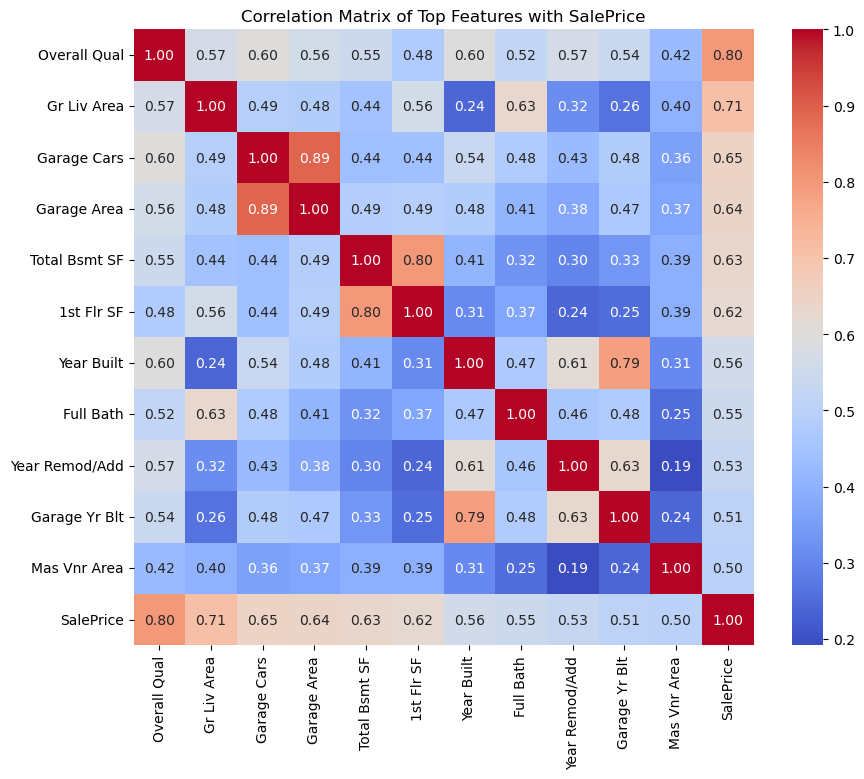

In [16]:
# Create a list of the top features PLUS SalePrice so it shows up in the heatmap
plot_cols = top_features.index.tolist() + ['SalePrice'] 

plt.figure(figsize=(10, 8))

# Use the subset of the dataframe containing only our columns of interest
sns.heatmap(housing[plot_cols].corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")

plt.title("Correlation Matrix of Top Features with SalePrice")
plt.show()

In [17]:
# Filter for weak features
weak_features = correlations[abs(correlations) < 0.5].sort_values(ascending=False)

print("There are {} weakly correlated features with SalePrice:\n{}".format(len(weak_features), weak_features))

There are 27 weakly correlated features with SalePrice:
TotRms AbvGrd      0.495500
Fireplaces         0.474481
BsmtFin SF 1       0.432897
Lot Frontage       0.340078
Wood Deck SF       0.327220
Open Porch SF      0.312970
Half Bath          0.284909
Bsmt Full Bath     0.275917
2nd Flr SF         0.269222
Lot Area           0.266600
Bsmt Unf SF        0.182849
Bedroom AbvGr      0.143934
Screen Porch       0.112104
Pool Area          0.068392
Mo Sold            0.035191
3Ssn Porch         0.032209
BsmtFin SF 2       0.005974
Misc Val          -0.015704
Yr Sold           -0.030308
Order             -0.031644
Bsmt Half Bath    -0.035852
Low Qual Fin SF   -0.037673
MS SubClass       -0.085206
Overall Cond      -0.101763
Kitchen AbvGr     -0.119839
Enclosed Porch    -0.128833
PID               -0.246617
Name: SalePrice, dtype: float64


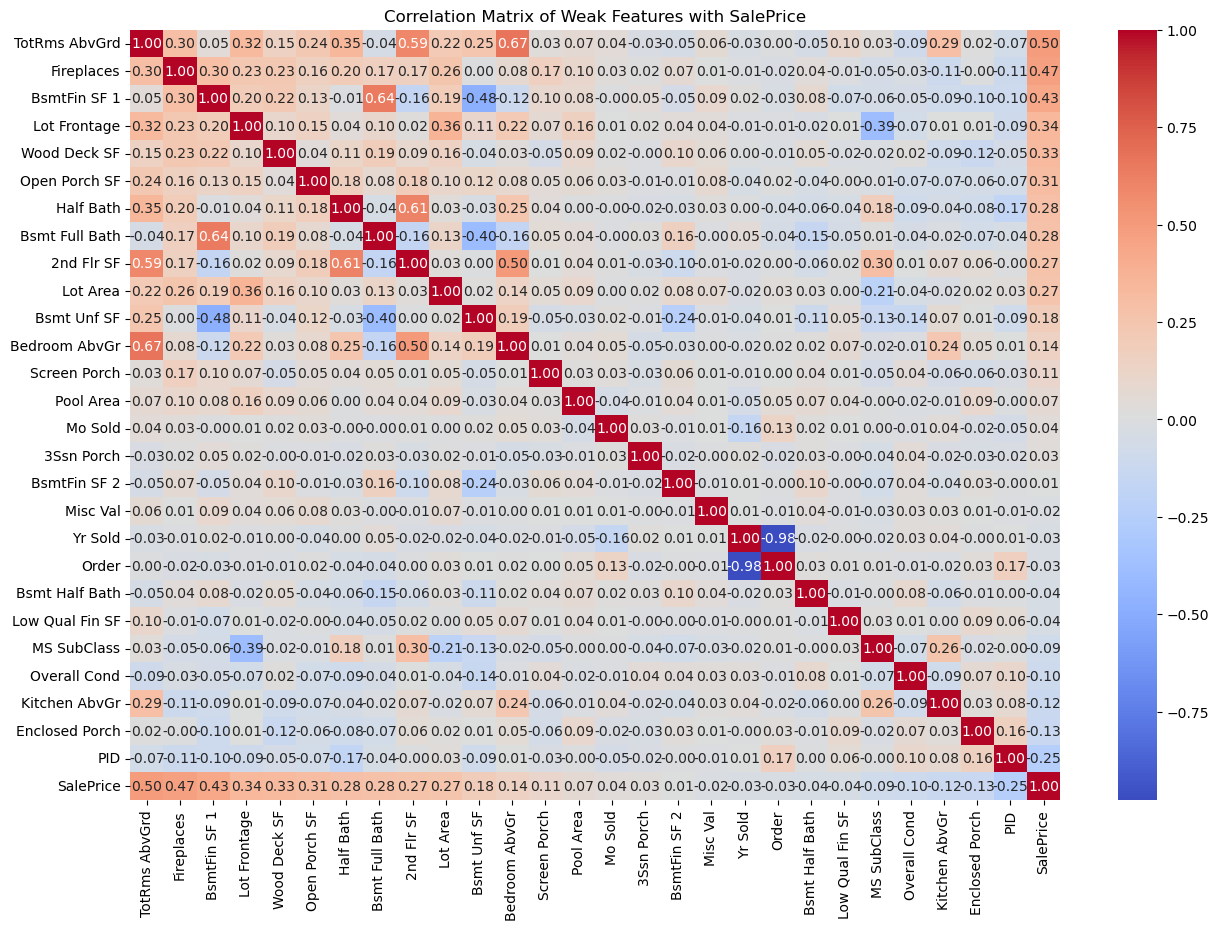

In [18]:
# Create a list of the weak features PLUS SalePrice so it shows up in the heatmap
plot_cols = weak_features.index.tolist() + ['SalePrice'] 

plt.figure(figsize=(15, 10))

# Use the subset of the dataframe containing only our columns of interest
sns.heatmap(housing[plot_cols].corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")

plt.title("Correlation Matrix of Weak Features with SalePrice")
plt.show()

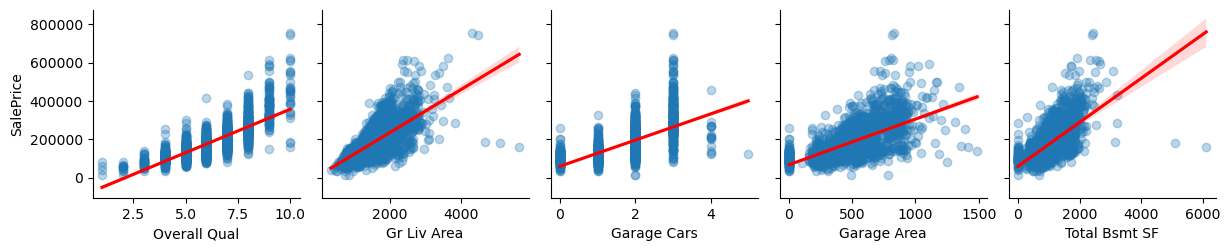

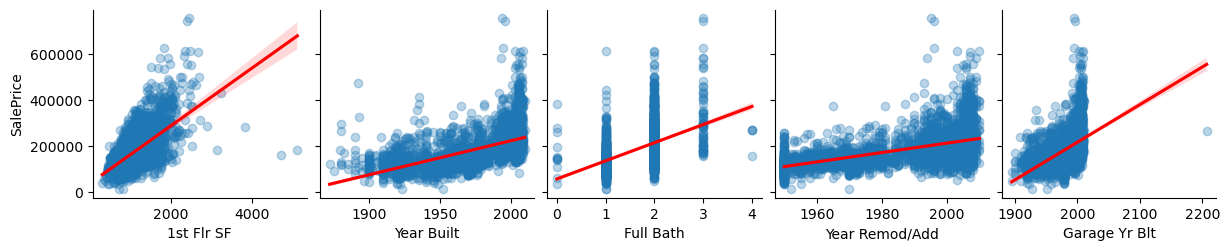

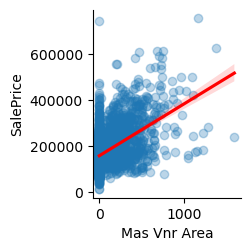

In [19]:
feature_names = top_features.index

for i in range(0, len(feature_names), 5):
    sns.pairplot(data=housing,
                 x_vars=feature_names[i:i+5], 
                 y_vars=['SalePrice'],
                 kind='reg',
                 plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.3}})

In [20]:
from scipy import stats

# 1. Get the list of your high-impact features
cols_to_check = top_features.index.tolist()

# 2. Calculate the absolute Z-scores for these features
# We use abs() because we want to catch outliers on both the high and low ends
z_scores = np.abs(stats.zscore(housing[cols_to_check]))

# 3. Create a "filter mask"
# This keeps rows where ALL features have a Z-score less than 3
housing_clean = housing[(z_scores < 3).all(axis=1)]

print(f"Rows before cleaning: {len(housing)}")
print(f"Rows after cleaning: {len(housing_clean)}")
print(f"Total outliers removed: {len(housing) - len(housing_clean)}")

Rows before cleaning: 2931
Rows after cleaning: 2803
Total outliers removed: 128


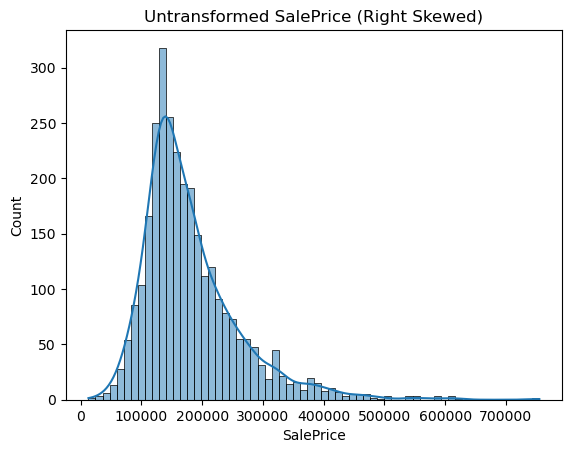

In [21]:
# Just visualizing the current "skewed" SalePrice
sns.histplot(housing['SalePrice'], kde=True)
plt.title("Untransformed SalePrice (Right Skewed)")
plt.show()

In [22]:
print("Skewness: %f " % housing['SalePrice'].skew())

Skewness: 1.743222 


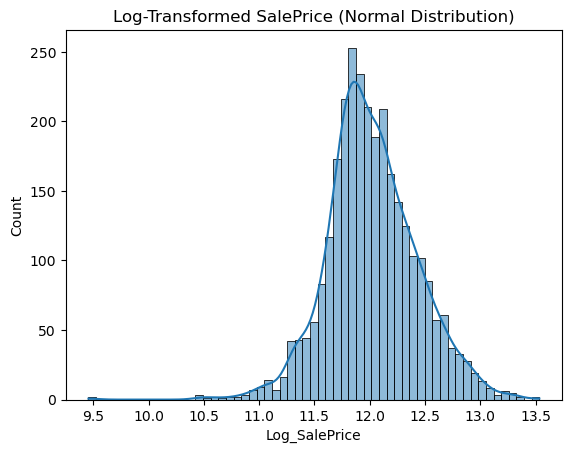

In [23]:
# Log-transforming SalePrice to reduce skewness and make it more normally distributed
housing['Log_SalePrice'] = np.log1p(housing['SalePrice']) 

sns.histplot(housing['Log_SalePrice'], kde=True)
plt.title("Log-Transformed SalePrice (Normal Distribution)")
plt.show()

In [24]:
print("Skewness: %f " % housing['Log_SalePrice'].skew())

Skewness: -0.015333 


# Feature Scaling

In [25]:
# Change 'housing' to 'housing_clean' here:
housing_clean['Log_SalePrice'] = np.log1p(housing_clean['SalePrice'])

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Select your top features
cols_to_scale = top_features.index.tolist()

# 3. Fit and transform using the CLEANED data
scaled_array = scaler.fit_transform(housing_clean[cols_to_scale])

# 4. Convert back to a DataFrame
housing_scaled = pd.DataFrame(scaled_array, columns=cols_to_scale)

# 5. Add your target back from the CLEANED data (This will now work!)
housing_scaled['Log_SalePrice'] = housing_clean['Log_SalePrice'].values

print(housing_scaled.head())

   Overall Qual  Gr Liv Area  Garage Cars  Garage Area  Total Bsmt SF  \
0     -0.026036     0.446530     0.361717     0.331443       0.135592   
1     -0.026036     0.446530     0.361717     0.331443       0.135592   
2     -0.770715    -1.272338    -0.997389     1.333695      -0.369888   
3     -0.026036    -0.293036    -0.997389    -0.740273       0.771271   
4      0.718643     1.473327     0.361717     0.301673       2.765108   

   1st Flr SF  Year Built  Full Bath  Year Remod/Add  Garage Yr Blt  \
0    1.524104   -0.377929  -1.018458       -1.140959      -0.736337   
1    1.524104   -0.377929  -1.018458       -1.140959      -0.736337   
2   -0.685341   -0.344222  -1.018458       -1.093148      -0.694985   
3    0.573461   -0.445342  -1.018458       -1.236579      -0.819040   
4    2.843957   -0.108275   0.849826       -0.758478      -0.405522   

   Mas Vnr Area  Log_SalePrice  
0      0.205615      12.278398  
1      0.205615      12.278398  
2     -0.617285      11.561725  
3 

In [26]:
housing_scaled[cols_to_scale].describe().round(2)

,Overall Qual,Gr Liv Area,Garage Cars,Garage Area,Total Bsmt SF,1st Flr SF,Year Built,Full Bath,Year Remod/Add,Garage Yr Blt,Mas Vnr Area
count,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00,2803.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.00,-2.38,-2.36,-2.29,-2.62,-2.21,-3.01,-2.89,-1.62,-2.97,-0.62
25%,-0.77,-0.77,-1.00,-0.73,-0.61,-0.76,-0.58,-1.02,-0.90,-0.69,-0.62
50%,-0.03,-0.08,0.36,0.06,-0.12,-0.17,0.03,0.85,0.39,0.05,-0.62
75%,0.72,0.58,0.36,0.57,0.61,0.67,0.97,0.85,0.96,0.96,0.45
max,2.95,3.50,3.08,3.19,3.04,3.28,1.31,2.72,1.25,1.33,4.04


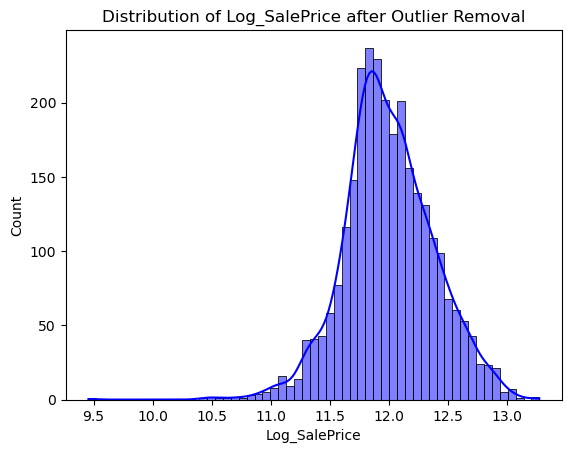

In [27]:
sns.histplot(housing_clean['Log_SalePrice'], kde=True, color='blue')
plt.title("Distribution of Log_SalePrice after Outlier Removal")
plt.show()

In [28]:
print("Skewness: %f " % housing_clean['Log_SalePrice'].skew())

Skewness: -0.117084 


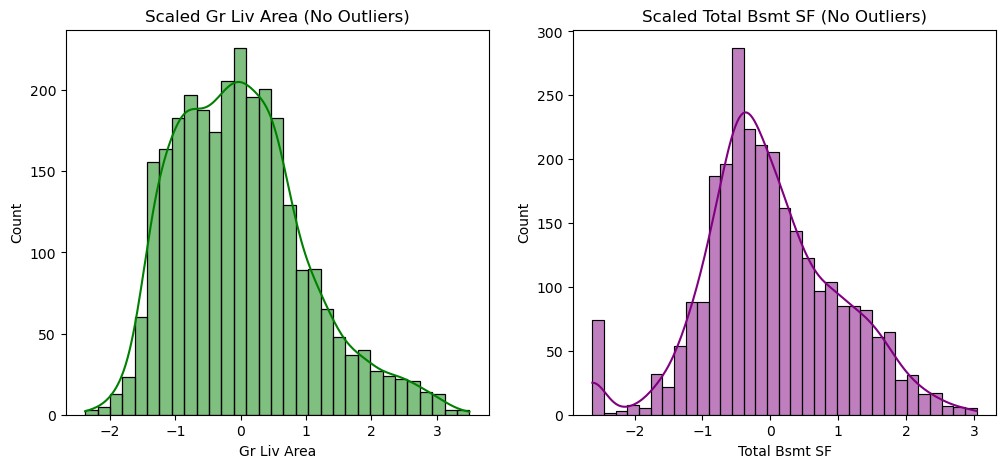

In [29]:
# Check a few top features to see the effect of scaling and outlier removal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(housing_scaled['Gr Liv Area'], kde=True, ax=axes[0], color='green')
axes[0].set_title("Scaled Gr Liv Area (No Outliers)")

sns.histplot(housing_scaled['Total Bsmt SF'], kde=True, ax=axes[1], color='purple')
axes[1].set_title("Scaled Total Bsmt SF (No Outliers)")

plt.show()

# Linear Regression

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# 1. Select your top numerical features
X_numeric = housing_clean[top_features.index]

# 2. Select and encode your specific categorical features
cat_cols = ['Neighborhood', 'Exter Qual', 'Kitchen Qual', 'Foundation']
X_categorical = pd.get_dummies(housing_clean[cat_cols], drop_first=True)

# 3. Combine them into one clean dataframe
# This ensures X contains ONLY numbers
X = pd.concat([X_numeric, X_categorical], axis=1)
y = housing_clean['Log_SalePrice']

# 4. Now the Split and Scale will work perfectly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train and Check results
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

print(f"R2 Squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred):.4f}")


R2 Squared Score: 0.8925
RMSE: 0.0159


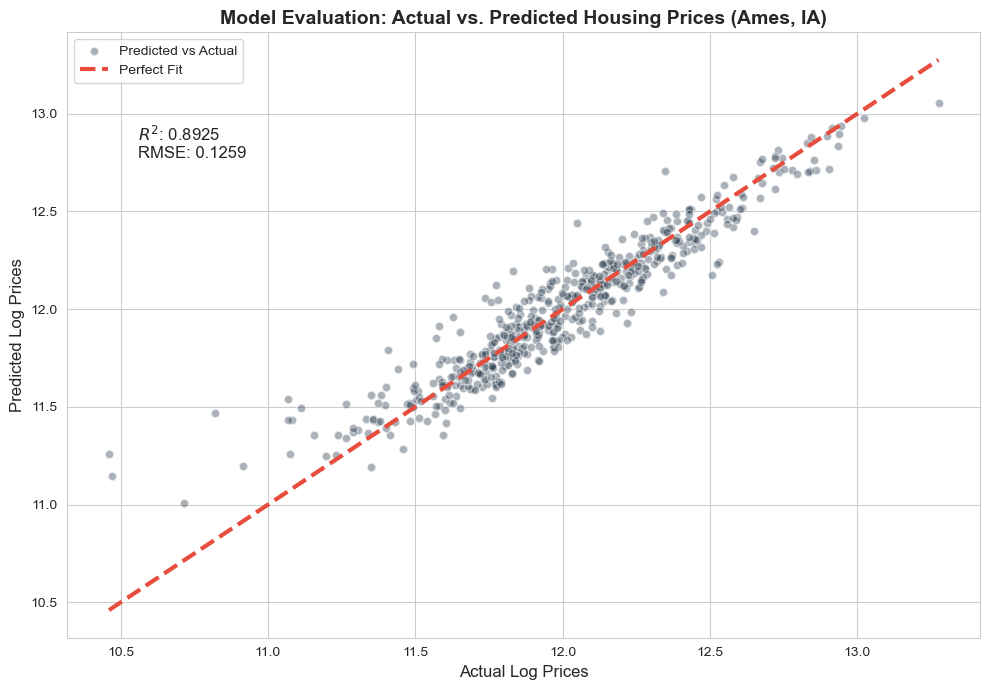

In [31]:

# 1. Set the style for a professional look
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# 2. Create the scatter plot
# We use a slightly smaller alpha and a color that pops
plt.scatter(y_test, y_pred, alpha=0.4, color='#2c3e50', edgecolors='w', label='Predicted vs Actual')

# 3. Add the "Perfect Prediction" Line (Identity Line)
# This represents where the dots would be if your model was 100% accurate
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='#e74c3c', lw=3, linestyle='--', label='Perfect Fit')

# 4. Add Metrics directly onto the plot (The "Pro" touch)
stats_text = f"$R^2$: {r2_score(y_test, y_pred):.4f}\nRMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}"
plt.text(y_test.min() + 0.1, y_test.max() - 0.5, stats_text, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# 5. Labels and Titles
plt.xlabel("Actual Log Prices", fontsize=12)
plt.ylabel("Predicted Log Prices", fontsize=12)
plt.title("Model Evaluation: Actual vs. Predicted Housing Prices (Ames, IA)", fontsize=14, fontweight='bold')
plt.legend(loc='upper left')

# 6. Final Polish
plt.tight_layout()
plt.show()

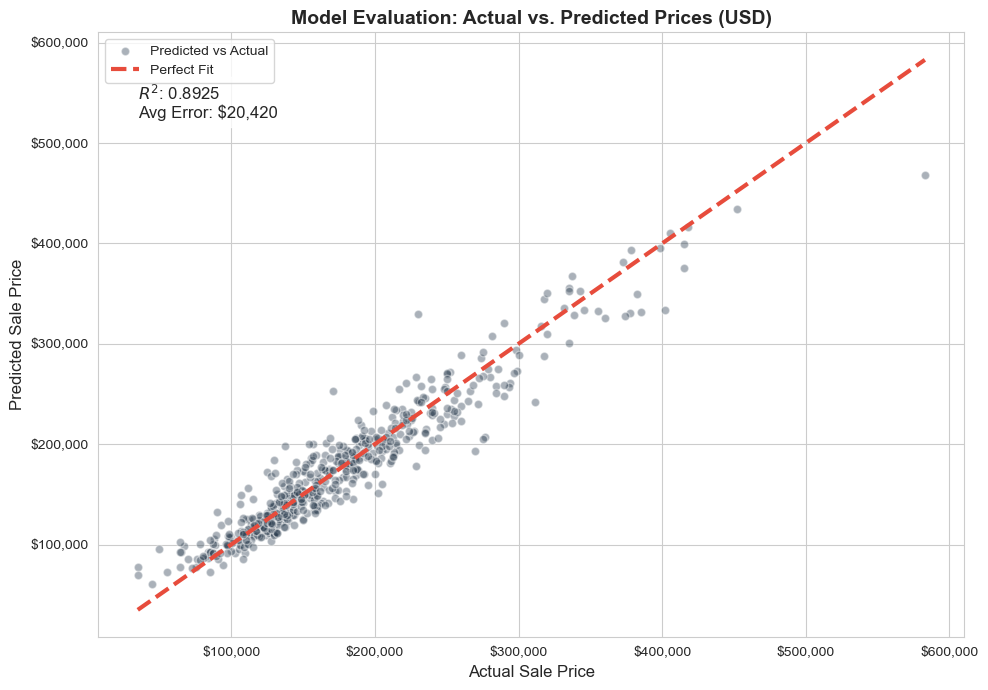

In [32]:
import matplotlib.ticker as ticker

# 1. Transform your data back to actual dollars
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred)

# 2. Set the style
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# 3. Create the scatter plot
plt.scatter(y_test_dollars, y_pred_dollars, alpha=0.4, color='#2c3e50', edgecolors='w', label='Predicted vs Actual')

# 4. Add the Identity Line (Perfect Fit)
line_coords = [y_test_dollars.min(), y_test_dollars.max()]
plt.plot(line_coords, line_coords, color='#e74c3c', lw=3, linestyle='--', label='Perfect Fit')

# 5. Add Metrics (R-squared stays the same, but RMSE is now in Dollars!)
r2 = r2_score(y_test, y_pred) # R2 is usually reported on the log-scale for this data
# We'll calculate a new "Dollar RMSE" for the text box
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

stats_text = f"$R^2$: {r2:.4f}\nAvg Error: ${rmse_dollars:,.0f}"
plt.text(y_test_dollars.min(), y_test_dollars.max() * 0.9, stats_text, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# 6. Formatting the Axes to show Currency
formatter = ticker.StrMethodFormatter('${x:,.0f}')
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# 7. Labels and Titles
plt.xlabel("Actual Sale Price", fontsize=12)
plt.ylabel("Predicted Sale Price", fontsize=12)
plt.title("Model Evaluation: Actual vs. Predicted Prices (USD)", fontsize=14, fontweight='bold')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

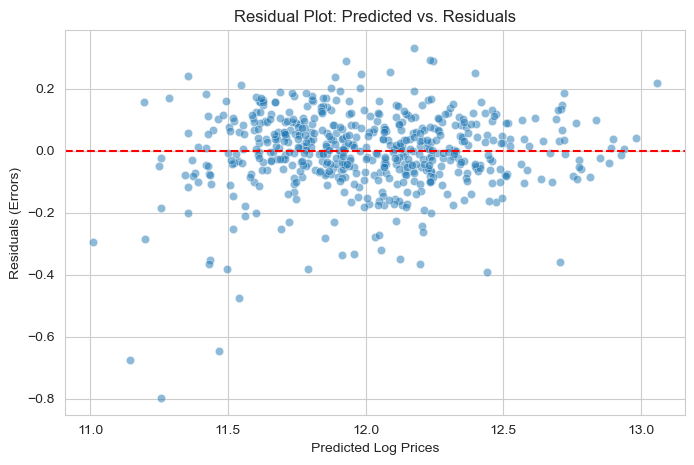

In [33]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Log Prices")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot: Predicted vs. Residuals")
plt.show()

#  Ridge and Lasso Model

In [34]:
from sklearn.linear_model import Ridge, Lasso

# 1. Initialize models
# alpha is the 'strength' of the penalty. 1.0 is a good starting point.
ridge_mod = Ridge(alpha=1.0)
lasso_mod = Lasso(alpha=0.0005) # Smaller alpha is better when using Log prices

# 2. Fit models
ridge_mod.fit(X_train_scaled, y_train)
lasso_mod.fit(X_train_scaled, y_train)

# 3. Compare R2 Scores
print(f"Linear R2: {r2_score(y_test, y_pred):.4f}")
print(f"Ridge R2:  {r2_score(y_test, ridge_mod.predict(X_test_scaled)):.4f}")
print(f"Lasso R2:  {r2_score(y_test, lasso_mod.predict(X_test_scaled)):.4f}")

Linear R2: 0.8925
Ridge R2:  0.8926
Lasso R2:  0.8932


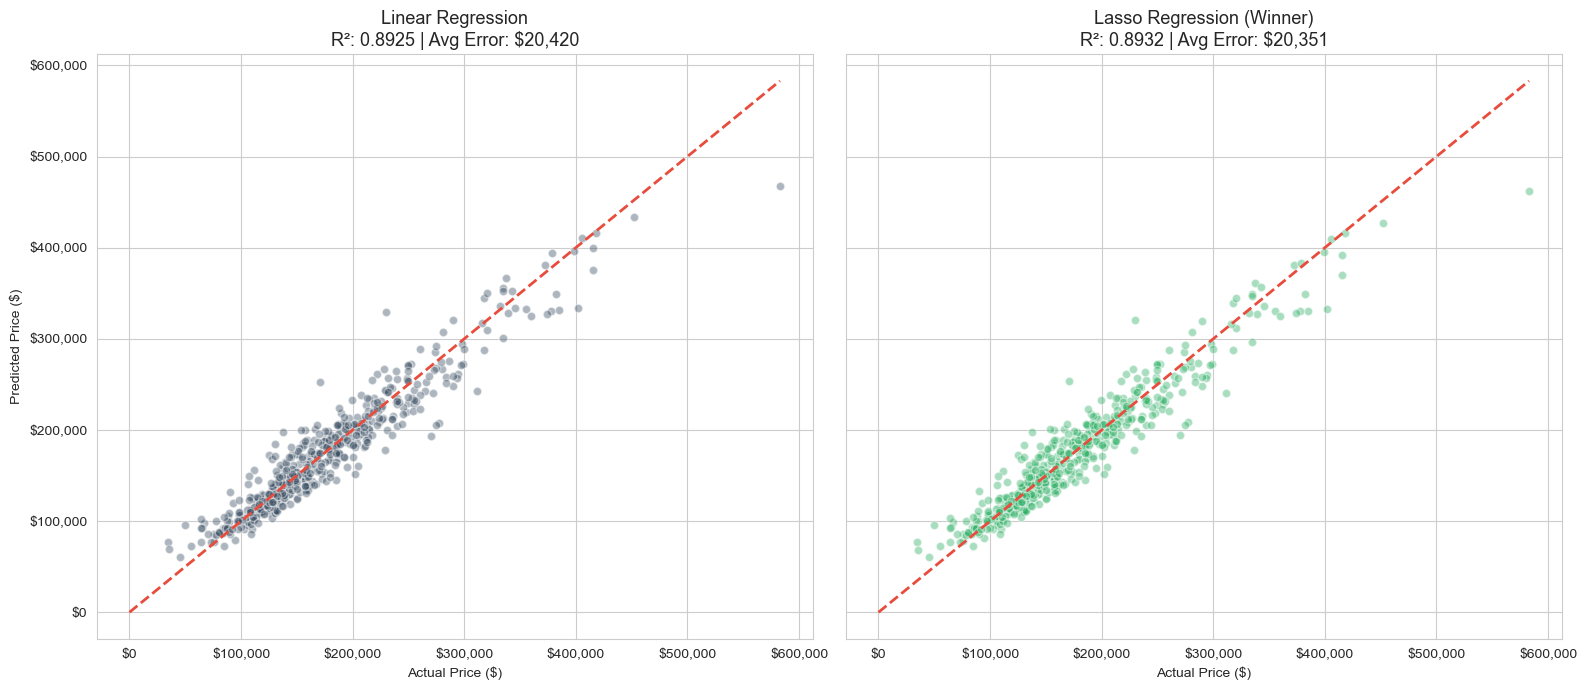

In [36]:
lm = LinearRegression()
lasso_mod = Lasso(alpha=0.0005)
lm.fit(X_train_scaled, y_train)
lasso_mod.fit(X_train_scaled, y_train)

# 1. Generate predictions for both
# (Assuming your models are named 'lm' and 'lasso_mod')
y_pred_lin = lm.predict(X_test_scaled)
y_pred_lasso = lasso_mod.predict(X_test_scaled)

# 2. Transform back to actual dollars (Variable names fixed)
y_test_usd = np.expm1(y_test)
y_lin_usd = np.expm1(y_pred_lin)
y_lasso_usd = np.expm1(y_pred_lasso)

# 3. Setup the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.set_style("whitegrid")

# --- PLOT 1: LINEAR REGRESSION ---
ax1.scatter(y_test_usd, y_lin_usd, alpha=0.4, color='#34495e', edgecolors='w')
ax1.plot([0, y_test_usd.max()], [0, y_test_usd.max()], '--', color='#e74c3c', lw=2)
lin_r2 = r2_score(y_test, y_pred_lin)
lin_rmse = np.sqrt(mean_squared_error(y_test_usd, y_lin_usd))
ax1.set_title(f"Linear Regression\nR²: {lin_r2:.4f} | Avg Error: ${lin_rmse:,.0f}", fontsize=13)
ax1.set_xlabel("Actual Price ($)")
ax1.set_ylabel("Predicted Price ($)")

# --- PLOT 2: LASSO REGRESSION ---
ax2.scatter(y_test_usd, y_lasso_usd, alpha=0.4, color='#27ae60', edgecolors='w')
ax2.plot([0, y_test_usd.max()], [0, y_test_usd.max()], '--', color='#e74c3c', lw=2)
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test_usd, y_lasso_usd))
ax2.set_title(f"Lasso Regression (Winner)\nR²: {lasso_r2:.4f} | Avg Error: ${lasso_rmse:,.0f}", fontsize=13)
ax2.set_xlabel("Actual Price ($)")

# 4. Format axes as currency
formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax1.xaxis.set_major_formatter(formatter)
ax1.yaxis.set_major_formatter(formatter)
ax2.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

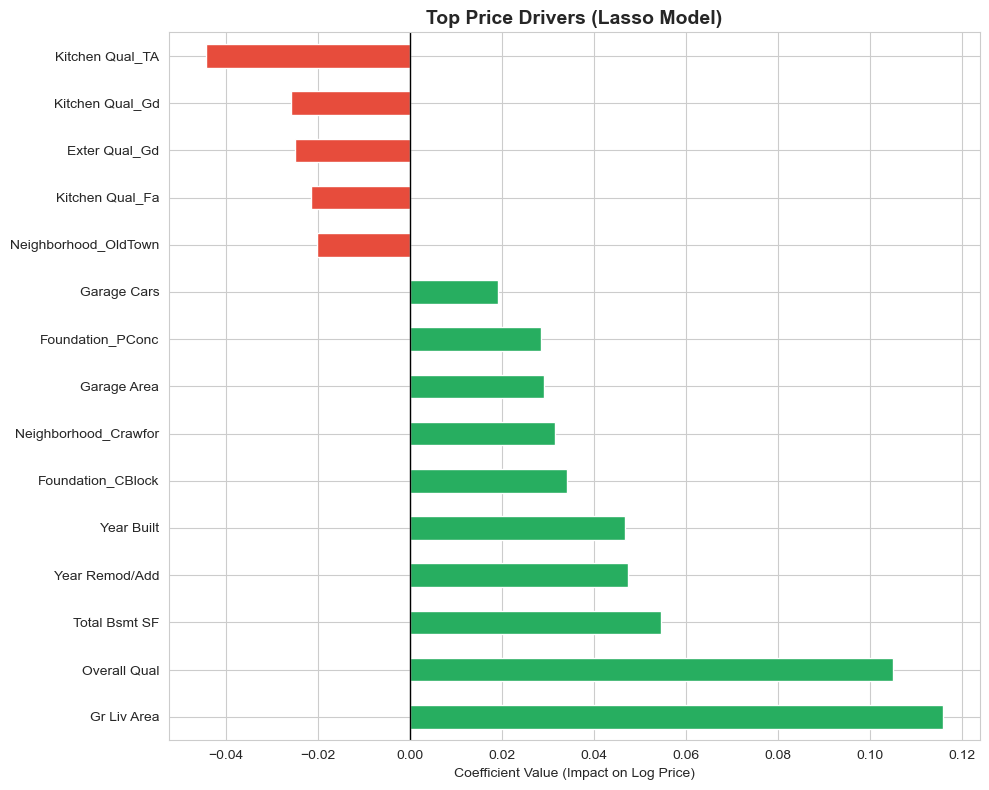

In [37]:
# 1. Create a Series for the coefficients
coef_series = pd.Series(lasso_mod.coef_, index=X.columns)

# 2. Sort them to see the biggest positive and negative impacts
top_10_coefs = coef_series.sort_values(ascending=False).head(10)
bottom_5_coefs = coef_series.sort_values(ascending=False).tail(5)

# 3. Combine and Plot
impact_plot = pd.concat([top_10_coefs, bottom_5_coefs])

plt.figure(figsize=(10, 8))
impact_plot.plot(kind='barh', color=(impact_plot > 0).map({True: '#27ae60', False: '#e74c3c'}))
plt.title("Top Price Drivers (Lasso Model)", fontsize=14, fontweight='bold')
plt.xlabel("Coefficient Value (Impact on Log Price)")
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()